In [36]:
import pandas as pd   

file_path = r"C:\Users\BHAVANA_CLRI\Documents\Bhavana\Data\Gdataset.xlsx"   

df = pd.read_excel(file_path)

print("Shape of the dataset (rows, columns):", df.shape)
print("\nFirst few rows of the dataset:")
print(df.head())

print("\nColumn names detected:")
print(df.columns.tolist())


Shape of the dataset (rows, columns): (203, 6)

First few rows of the dataset:
     SlNO  F1-1940  F2-2041  F3-2176  F4-2283    Category
0  1PSN-1  0.49988  0.17427  0.09332  0.08806  WL-NM-PICK
1  1PSN-2  0.46907  0.15274  0.09643  0.10723  WL-NM-PICK
2  1PSN-3  0.47379  0.17235  0.11374  0.10208  WL-NM-PICK
3  1PSN-4  0.47864  0.16277  0.10060  0.10294  WL-NM-PICK
4  1PSN-5  0.48854  0.18647  0.10906  0.10577  WL-NM-PICK

Column names detected:
['SlNO', 'F1-1940', 'F2-2041', 'F3-2176', 'F4-2283', 'Category']


In [37]:
print("\n=== Dataset Info ===")
df.info()

print("\n=== Missing Values Per Column ===")
print(df.isnull().sum())

print("\n=== Statistical Summary (Numeric Columns) ===")
print(df.describe().T)

print("\n=== Statistical Summary (Categorical Columns) ===")
print(df.describe(include=['object']).T)



=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203 entries, 0 to 202
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SlNO      203 non-null    object 
 1   F1-1940   203 non-null    float64
 2   F2-2041   203 non-null    float64
 3   F3-2176   203 non-null    float64
 4   F4-2283   203 non-null    float64
 5   Category  203 non-null    object 
dtypes: float64(4), object(2)
memory usage: 9.6+ KB

=== Missing Values Per Column ===
SlNO        0
F1-1940     0
F2-2041     0
F3-2176     0
F4-2283     0
Category    0
dtype: int64

=== Statistical Summary (Numeric Columns) ===
         count      mean       std      min      25%      50%       75%  \
F1-1940  203.0  0.457655  0.050852  0.33386  0.40267  0.48414  0.496515   
F2-2041  203.0  0.145183  0.038602  0.06177  0.09756  0.16503  0.174530   
F3-2176  203.0  0.088571  0.016881  0.04055  0.07799  0.08931  0.101355   
F4-2283  203.0  0.095017  0.015

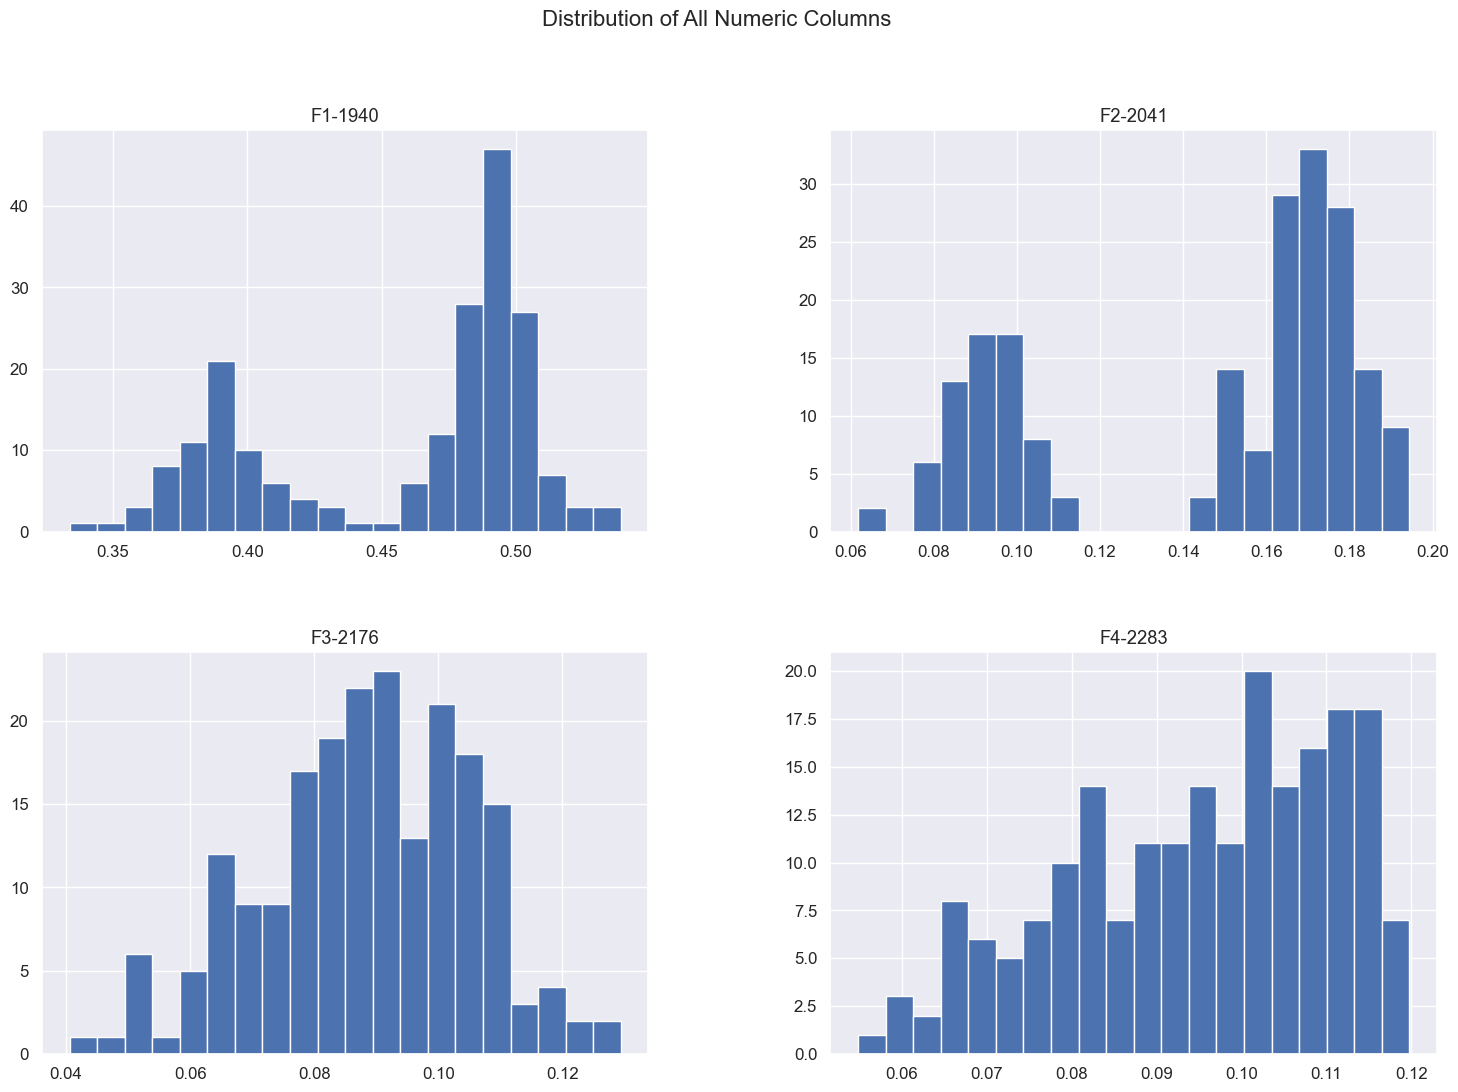

In [38]:
import matplotlib.pyplot as plt
df.hist(figsize=(18, 12), bins=20)
plt.suptitle("Distribution of All Numeric Columns", fontsize=16)
plt.show()


Mutual Information Scores:
F1-1940    0.650406
F2-2041    0.642333
F3-2176    0.565152
F4-2283    0.438930
dtype: float64


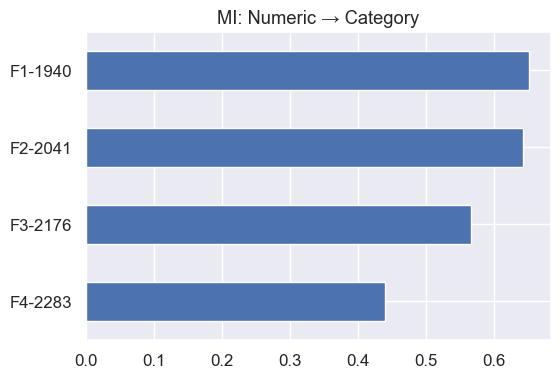

In [39]:
from sklearn.feature_selection import mutual_info_classif

X = df[['F1-1940', 'F2-2041', 'F3-2176', 'F4-2283']]
y = df['Category']

mi = mutual_info_classif(X, y, random_state=42)
mi_series = pd.Series(mi, index=X.columns)

print("Mutual Information Scores:")
print(mi_series.sort_values(ascending=False))

mi_series.sort_values().plot(kind='barh', figsize=(6,4), title="MI: Numeric → Category")
plt.show()


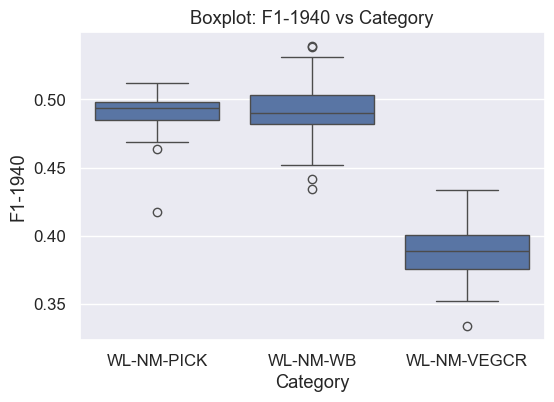

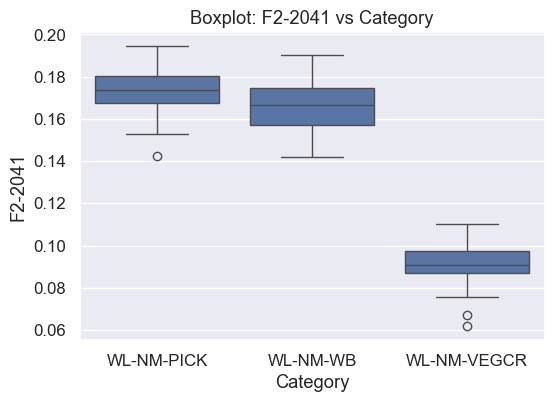

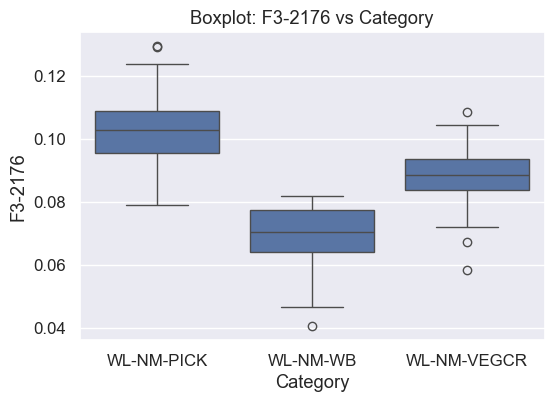

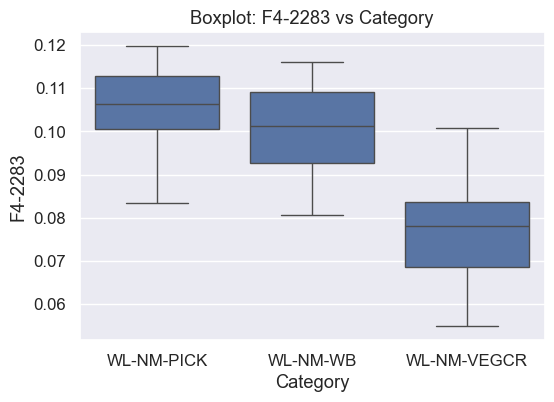

In [40]:
for col in ['F1-1940', 'F2-2041', 'F3-2176', 'F4-2283']:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Category', y=col, data=df)
    plt.title(f"Boxplot: {col} vs Category")
    plt.show()


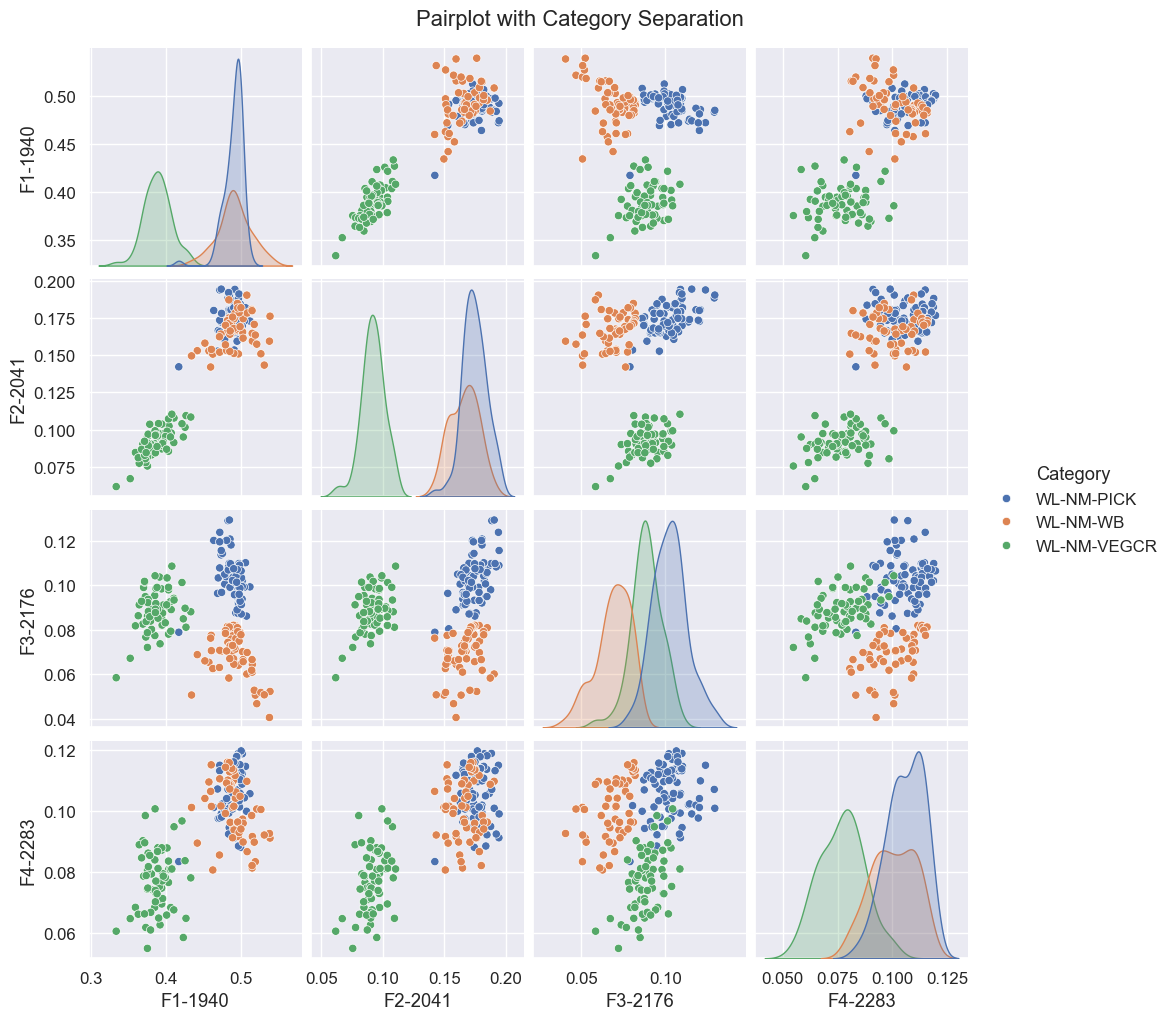

In [41]:
numeric_cols = ['F1-1940', 'F2-2041', 'F3-2176', 'F4-2283']
numeric_df = df[numeric_cols]
sns.pairplot(df, vars=numeric_cols, hue="Category", diag_kind="kde")
plt.suptitle("Pairplot with Category Separation", y=1.02)
plt.show()


In [45]:
from sklearn.preprocessing import LabelEncoder, LabelBinarizer
from sklearn.model_selection import train_test_split
import pandas as pd

# Encode the Category column
label_encoder = LabelEncoder()
df["Category_encoded"] = label_encoder.fit_transform(df["Category"])

print("Label mapping (text → number):")
for class_name, encoded_value in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(f"{class_name} --> {encoded_value}")

# Features & target
X = df[["F1-1940", "F2-2041", "F3-2176", "F4-2283"]]
y = df["Category_encoded"]

# Train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("\nTraining set size:", X_train.shape)
print("Testing set size:", X_test.shape)

# Save feature names for feature importance
feature_names = X_train.columns


Label mapping (text → number):
WL-NM-PICK --> 0
WL-NM-VEGCR --> 1
WL-NM-WB --> 2

Training set size: (162, 4)
Testing set size: (41, 4)


In [46]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"\nRandom Forest Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=label_encoder.classes_
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))



Random Forest Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

  WL-NM-PICK       1.00      1.00      1.00        16
 WL-NM-VEGCR       1.00      1.00      1.00        13
    WL-NM-WB       1.00      1.00      1.00        12

    accuracy                           1.00        41
   macro avg       1.00      1.00      1.00        41
weighted avg       1.00      1.00      1.00        41

Confusion Matrix:
[[16  0  0]
 [ 0 13  0]
 [ 0  0 12]]


In [52]:
import numpy as np

# Feature Importance
feature_names = X.columns
importances = rf.feature_importances_

# Combine names and scores
for name, score in zip(feature_names, importances):
    print(f"{name}: {score:.4f}")

F1-1940: 0.2334
F2-2041: 0.3181
F3-2176: 0.3905
F4-2283: 0.0580


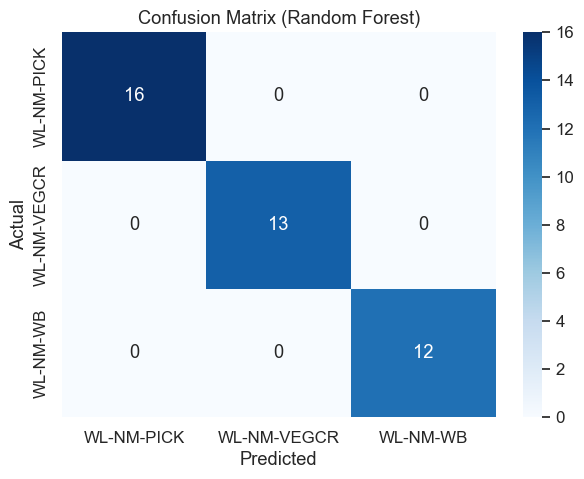

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Confusion Matrix (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



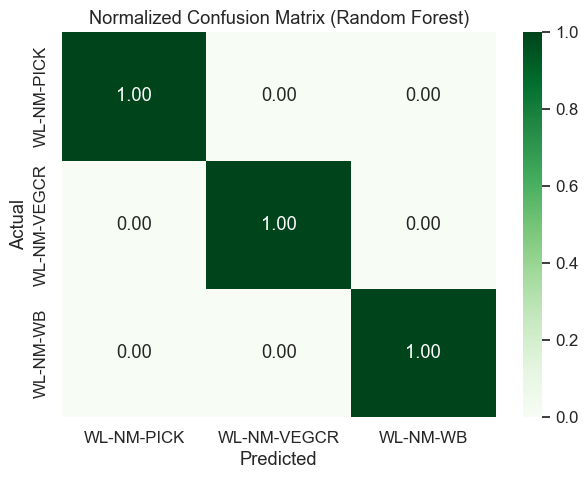

In [48]:
cm_norm = confusion_matrix(y_test, y_pred, normalize="true")

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Normalized Confusion Matrix (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


C:\Users\BHAVANA_CLRI\AppData\Local\Temp\ipykernel_5284\3128684179.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


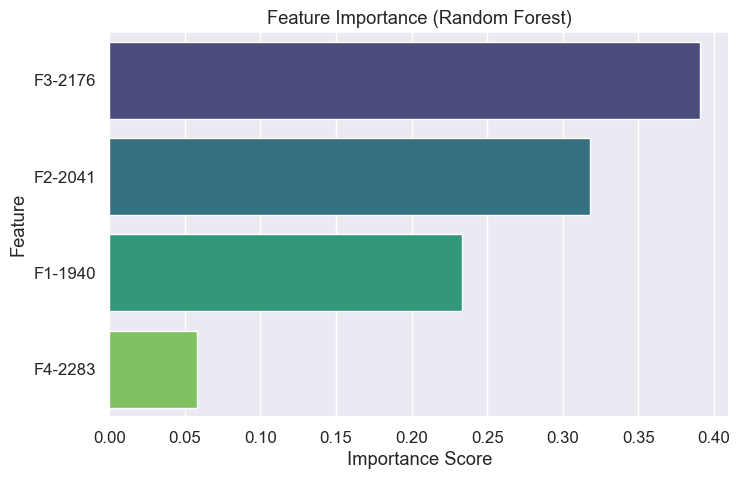

In [49]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 5))
sns.barplot(
    x=importances[indices],
    y=np.array(feature_names)[indices],
    palette="viridis"
)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

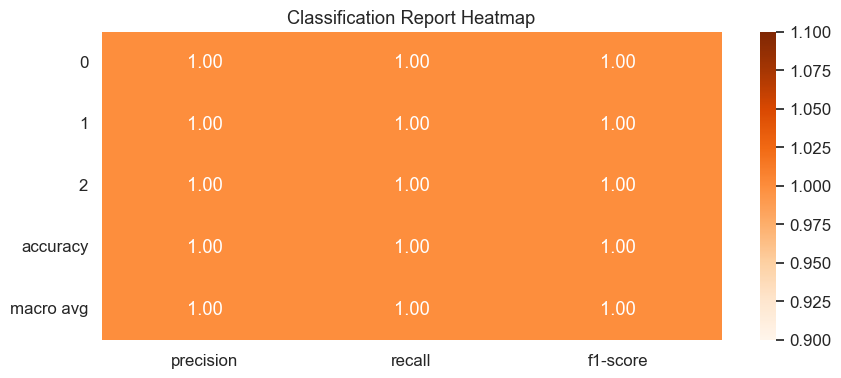

In [50]:
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).T

plt.figure(figsize=(10, 4))
sns.heatmap(
    report_df.iloc[:-1, :-1],
    annot=True,
    cmap="Oranges",
    fmt=".2f"
)
plt.title("Classification Report Heatmap")
plt.show()


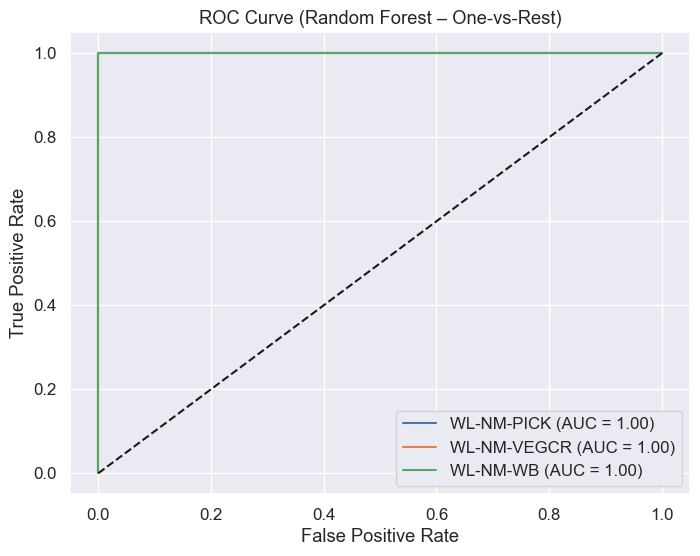

In [51]:
from sklearn.metrics import roc_curve, auc

label_binarizer = LabelBinarizer()
y_test_bin = label_binarizer.fit_transform(y_test)
y_pred_prob = rf.predict_proba(X_test)

plt.figure(figsize=(8, 6))

for i, class_name in enumerate(label_encoder.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Random Forest – One-vs-Rest)")
plt.legend()
plt.show()

In [53]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "SVM (RBF kernel)": SVC(kernel="rbf", probability=True),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# Train & evaluate
for name, model in models.items():
    if name in ["Logistic Regression", "KNN (k=5)", "SVM (RBF kernel)"]:
        model.fit(X_train_scaled, y_train)
        acc = model.score(X_test_scaled, y_test)
    else:
        model.fit(X_train, y_train)
        acc = model.score(X_test, y_test)
    
    print(f"{name} Accuracy: {acc:.4f}")


Logistic Regression Accuracy: 1.0000
KNN (k=5) Accuracy: 1.0000
SVM (RBF kernel) Accuracy: 1.0000
Decision Tree Accuracy: 0.9756
Gradient Boosting Accuracy: 1.0000


In [54]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

results = {}

for name, model in models.items():

    # Use scaled data for LR, KNN, SVM
    if name in ["Logistic Regression", "KNN (k=5)", "SVM (RBF kernel)"]:
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)

    # Store metrics
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1 Score": f1_score(y_test, y_pred, average="weighted")
    }

    # Print metrics
    print("\n==============================")
    print(f"Model: {name}")
    print("==============================")
    print(f"Accuracy      : {results[name]['Accuracy']:.4f}")
    print(f"Precision     : {results[name]['Precision']:.4f}")
    print(f"Recall        : {results[name]['Recall']:.4f}")
    print(f"F1 Score      : {results[name]['F1 Score']:.4f}")
    
    # Confusion Matrix
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))



Model: Logistic Regression
Accuracy      : 1.0000
Precision     : 1.0000
Recall        : 1.0000
F1 Score      : 1.0000

Confusion Matrix:
[[16  0  0]
 [ 0 13  0]
 [ 0  0 12]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        12

    accuracy                           1.00        41
   macro avg       1.00      1.00      1.00        41
weighted avg       1.00      1.00      1.00        41


Model: KNN (k=5)
Accuracy      : 1.0000
Precision     : 1.0000
Recall        : 1.0000
F1 Score      : 1.0000

Confusion Matrix:
[[16  0  0]
 [ 0 13  0]
 [ 0  0 12]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        12

    accurac

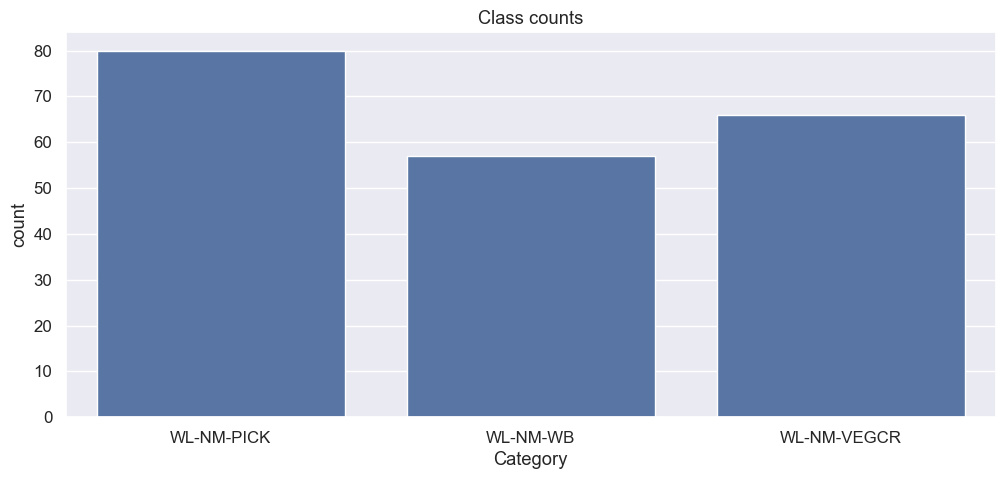

Train/test shapes: (162, 4) (41, 4)


In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV, train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix, roc_auc_score, roc_curve,
                             precision_recall_curve, average_precision_score, cohen_kappa_score,
                             matthews_corrcoef)
import warnings
warnings.filterwarnings("ignore")


X = df[["F1-1940","F2-2041","F3-2176","F4-2283"]].copy()
le = LabelEncoder()
if "Category_encoded" not in df.columns:
    df["Category_encoded"] = le.fit_transform(df["Category"])
else:
    le.fit(df["Category"].unique())  # ensure encoder has classes
y = df["Category_encoded"].values
class_names = le.classes_

plt.figure(figsize=(12,5))
sns.countplot(x=df["Category"])
plt.title("Class counts")
plt.show()


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Save scaler
joblib.dump(scaler, "scaler.joblib")

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=42, stratify=y)
print("Train/test shapes:", X_train.shape, X_test.shape)



In [57]:

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def cv_scores(model, X, y, folds=skf):
    acc = cross_val_score(model, X, y, cv=folds, scoring="accuracy", n_jobs=-1)
    f1_macro = cross_val_score(model, X, y, cv=folds, scoring="f1_macro", n_jobs=-1)
    return {"accuracy_mean": acc.mean(), "accuracy_std": acc.std(),
            "f1_macro_mean": f1_macro.mean(), "f1_macro_std": f1_macro.std()}


models_to_try = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(probability=True),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42)
}

cv_results = {}
for name, model in models_to_try.items():
    
    res = cv_scores(model, X_scaled, y)
    cv_results[name] = res
    print(f"{name}: acc {res['accuracy_mean']:.4f} ± {res['accuracy_std']:.4f}, f1_macro {res['f1_macro_mean']:.4f}")




LogisticRegression: acc 0.9901 ± 0.0121, f1_macro 0.9905
KNN: acc 0.9901 ± 0.0121, f1_macro 0.9905
SVM: acc 0.9901 ± 0.0121, f1_macro 0.9905
RandomForest: acc 0.9901 ± 0.0121, f1_macro 0.9905
GradientBoosting: acc 0.9851 ± 0.0199, f1_macro 0.9853


In [60]:
# Hyperparameter tuning (Randomized) 

from scipy.stats import randint, uniform
tuned_models = {}

# Random Forest random search
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_param_dist = {
    "n_estimators": randint(100, 500),
    "max_depth": randint(3, 30),
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 6),
    "max_features": ["auto", "sqrt", "log2", 0.5, None]
}
rf_search = RandomizedSearchCV(rf, rf_param_dist, n_iter=40, scoring="f1_macro", cv=skf, n_jobs=-1, random_state=42, verbose=1)
rf_search.fit(X_train, y_train)
print("RF best params:", rf_search.best_params_, "best score:", rf_search.best_score_)
best_rf = rf_search.best_estimator_
tuned_models["RandomForest"] = best_rf

# XGBoost
try:
    import xgboost as xgb
    xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", random_state=42, n_jobs=-1)
    xgb_param = {
        "n_estimators": randint(100,500),
        "max_depth": randint(3,12),
        "learning_rate": uniform(0.01, 0.3),
        "subsample": uniform(0.5, 0.5),
        "colsample_bytree": uniform(0.5, 0.5)
    }
    xgb_search = RandomizedSearchCV(xgb_clf, xgb_param, n_iter=40, scoring="f1_macro", cv=skf, n_jobs=-1, random_state=42, verbose=1)
    xgb_search.fit(X_train, y_train)
    print("XGB best:", xgb_search.best_params_, xgb_search.best_score_)
    tuned_models["XGBoost"] = xgb_search.best_estimator_
except Exception as e:
    print("XGBoost not available or failed to import; skipping XGBoost tuning.", e)



Fitting 5 folds for each of 40 candidates, totalling 200 fits
RF best params: {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 8, 'n_estimators': 221} best score: 0.9877777777777776
Fitting 5 folds for each of 40 candidates, totalling 200 fits
XGB best: {'colsample_bytree': np.float64(0.8540362888980227), 'learning_rate': np.float64(0.016175348288740735), 'max_depth': 4, 'n_estimators': 443, 'subsample': np.float64(0.9162213204002109)} 0.9877610693400168


=== RandomForest ===
Accuracy: 1.0
Balanced accuracy: 1.0
MCC: 1.0 Kappa: 1.0
              precision    recall  f1-score   support

  WL-NM-PICK       1.00      1.00      1.00        16
 WL-NM-VEGCR       1.00      1.00      1.00        13
    WL-NM-WB       1.00      1.00      1.00        12

    accuracy                           1.00        41
   macro avg       1.00      1.00      1.00        41
weighted avg       1.00      1.00      1.00        41

Confusion matrix:
 [[16  0  0]
 [ 0 13  0]
 [ 0  0 12]]


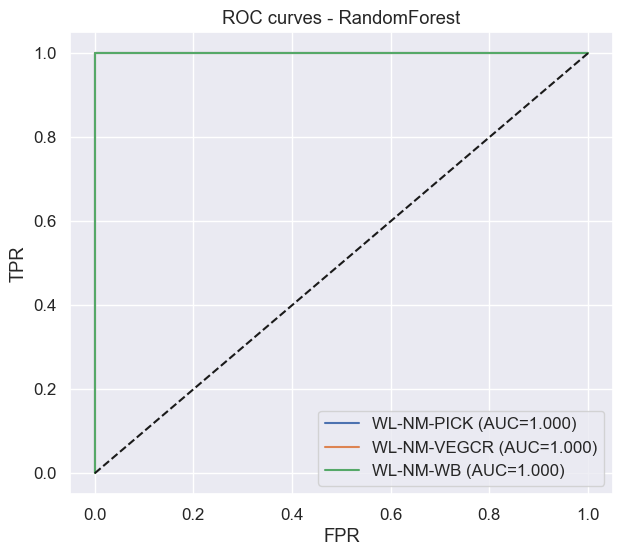

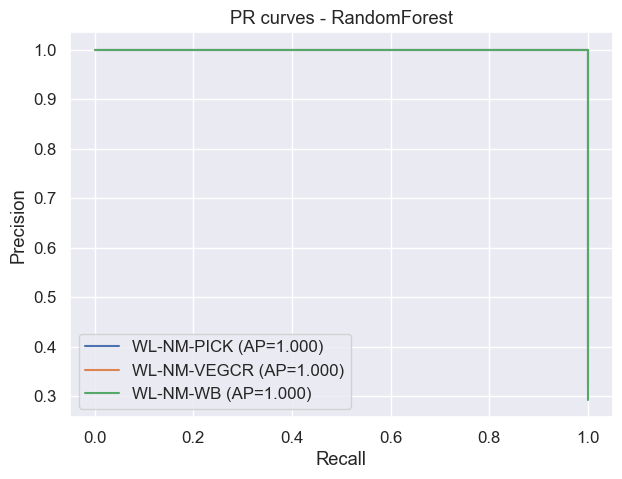

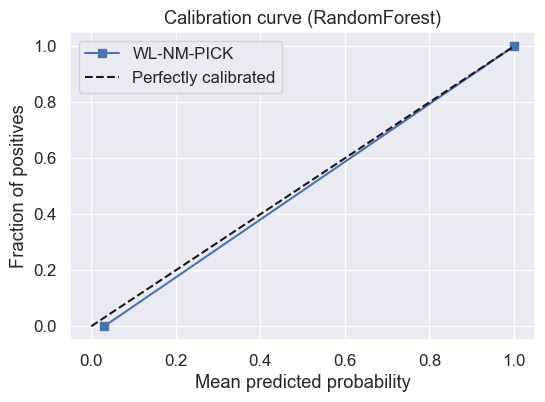

=== XGBoost ===
Accuracy: 0.975609756097561
Balanced accuracy: 0.9722222222222222
MCC: 0.96396552871733 Kappa: 0.963096309630963
              precision    recall  f1-score   support

  WL-NM-PICK       1.00      1.00      1.00        16
 WL-NM-VEGCR       0.93      1.00      0.96        13
    WL-NM-WB       1.00      0.92      0.96        12

    accuracy                           0.98        41
   macro avg       0.98      0.97      0.97        41
weighted avg       0.98      0.98      0.98        41

Confusion matrix:
 [[16  0  0]
 [ 0 13  0]
 [ 0  1 11]]


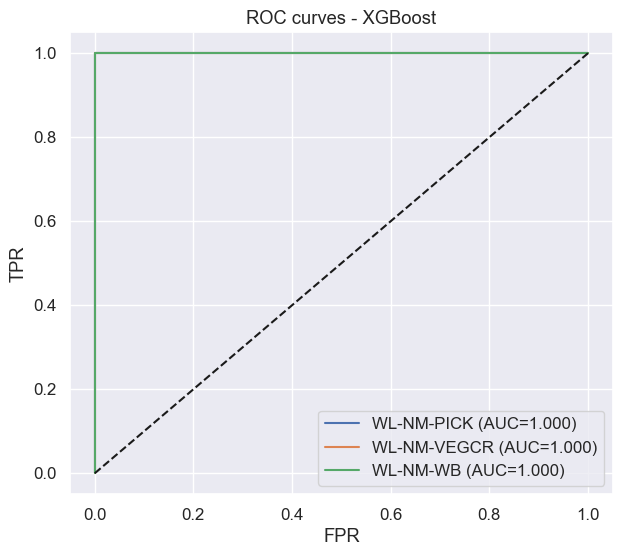

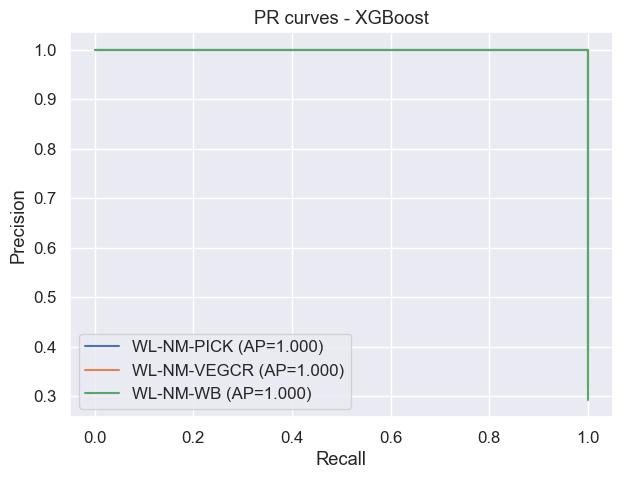

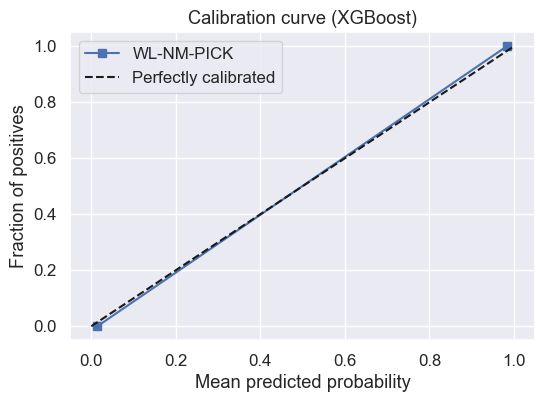

=== Stacking ===
Accuracy: 1.0
Balanced accuracy: 1.0
MCC: 1.0 Kappa: 1.0
              precision    recall  f1-score   support

  WL-NM-PICK       1.00      1.00      1.00        16
 WL-NM-VEGCR       1.00      1.00      1.00        13
    WL-NM-WB       1.00      1.00      1.00        12

    accuracy                           1.00        41
   macro avg       1.00      1.00      1.00        41
weighted avg       1.00      1.00      1.00        41

Confusion matrix:
 [[16  0  0]
 [ 0 13  0]
 [ 0  0 12]]


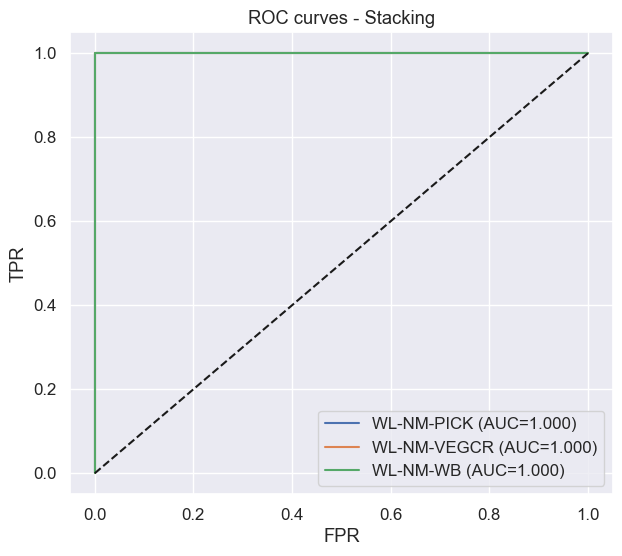

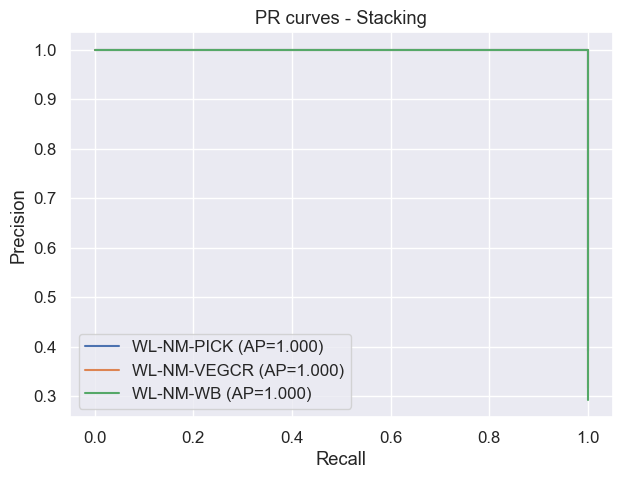

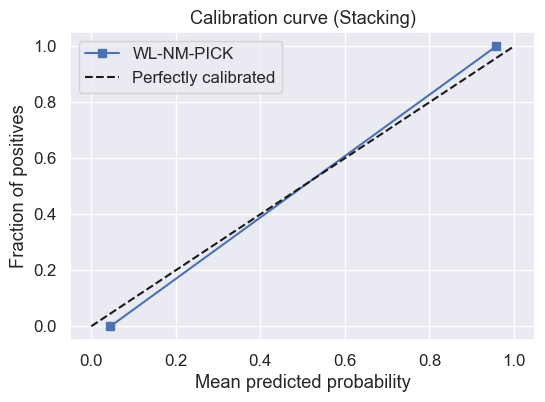

=== CalibratedRF ===
Accuracy: 1.0
Balanced accuracy: 1.0
MCC: 1.0 Kappa: 1.0
              precision    recall  f1-score   support

  WL-NM-PICK       1.00      1.00      1.00        16
 WL-NM-VEGCR       1.00      1.00      1.00        13
    WL-NM-WB       1.00      1.00      1.00        12

    accuracy                           1.00        41
   macro avg       1.00      1.00      1.00        41
weighted avg       1.00      1.00      1.00        41

Confusion matrix:
 [[16  0  0]
 [ 0 13  0]
 [ 0  0 12]]


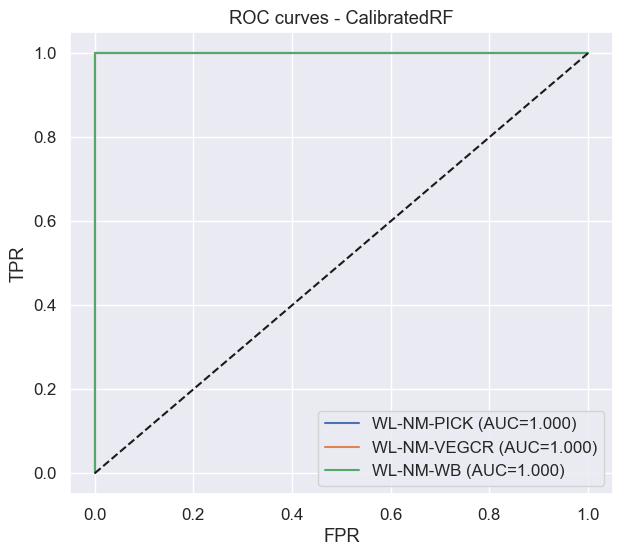

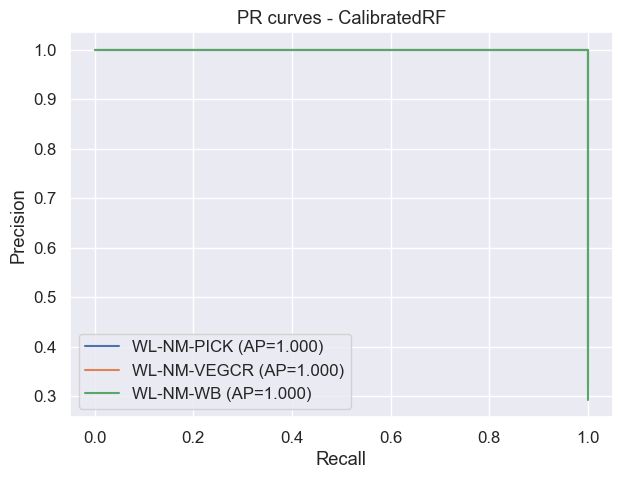

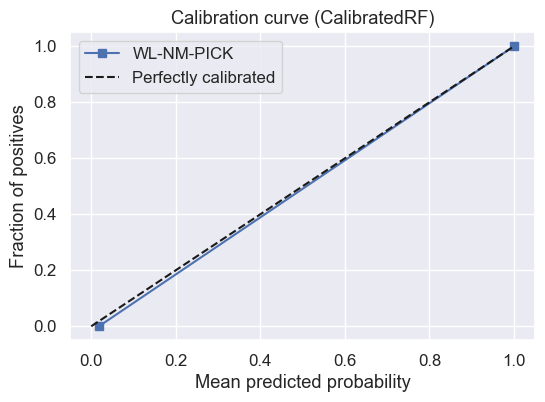

=== Stacking ===
Accuracy: 1.0
Balanced accuracy: 1.0
MCC: 1.0 Kappa: 1.0
              precision    recall  f1-score   support

  WL-NM-PICK       1.00      1.00      1.00        16
 WL-NM-VEGCR       1.00      1.00      1.00        13
    WL-NM-WB       1.00      1.00      1.00        12

    accuracy                           1.00        41
   macro avg       1.00      1.00      1.00        41
weighted avg       1.00      1.00      1.00        41

Confusion matrix:
 [[16  0  0]
 [ 0 13  0]
 [ 0  0 12]]


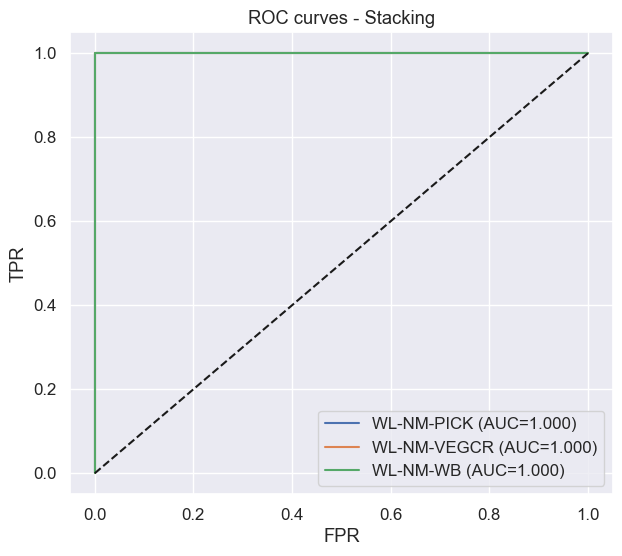

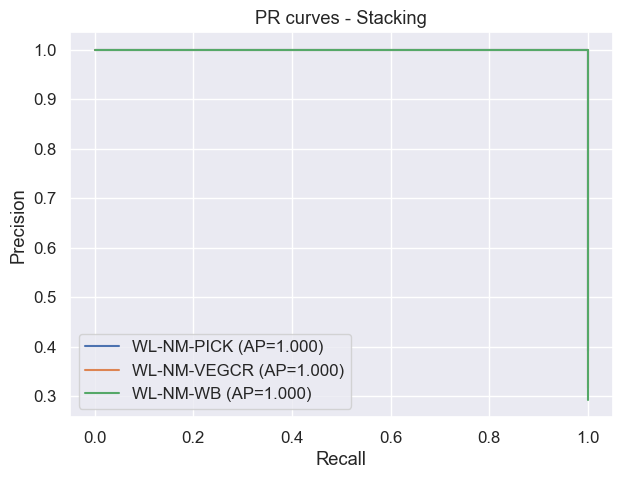

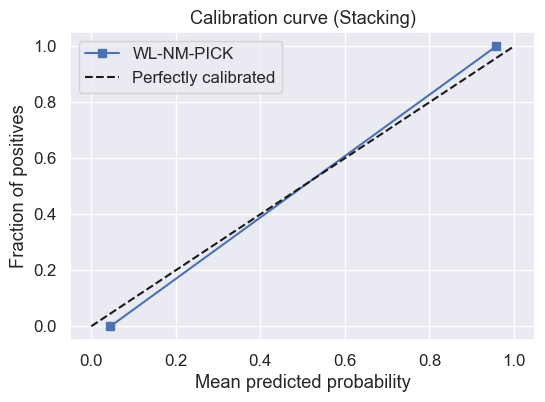

In [61]:
# Create a stacking classifier of top performing models
estimators = [
    ("rf", tuned_models.get("RandomForest", RandomForestClassifier(n_estimators=200, random_state=42))),
   
]
stack = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(), cv=skf, n_jobs=-1)
stack.fit(X_train, y_train)
tuned_models["Stacking"] = stack

# Probability calibration (
calibrated_rf = CalibratedClassifierCV(best_rf, method="isotonic", cv=skf)
calibrated_rf.fit(X_train, y_train)
tuned_models["CalibratedRF"] = calibrated_rf

#  Evaluate final models on test set with detailed metrics & plots 
def evaluate_model(model, X_test, y_test, title="Model"):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None
    
    acc = accuracy_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    prf = precision_recall_fscore_support(y_test, y_pred, average=None, zero_division=0)
    print(f"=== {title} ===")
    print("Accuracy:", acc)
    print("Balanced accuracy:", bal_acc)
    print("MCC:", mcc, "Kappa:", kappa)
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    
    # ROC (one-vs-rest)
    if y_proba is not None:
        try:
            from sklearn.preprocessing import label_binarize
            y_test_bin = label_binarize(y_test, classes=np.arange(len(le.classes_)))
            # plot ROC for each class
            plt.figure(figsize=(7,6))
            for i in range(y_test_bin.shape[1]):
                fpr, tpr, _ = roc_curve(y_test_bin[:,i], y_proba[:,i])
                auc = roc_auc_score(y_test_bin[:,i], y_proba[:,i])
                plt.plot(fpr, tpr, label=f"{le.classes_[i]} (AUC={auc:.3f})")
            plt.plot([0,1],[0,1],"k--")
            plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title(f"ROC curves - {title}"); plt.legend()
            plt.show()
        except Exception as e:
            print("ROC plotting failed:", e)
    
    # Precision-recall micro/macro
    if y_proba is not None:
        plt.figure(figsize=(7,5))
        for i in range(y_test_bin.shape[1]):
            prec, rec, _ = precision_recall_curve(y_test_bin[:,i], y_proba[:,i])
            ap = average_precision_score(y_test_bin[:,i], y_proba[:,i])
            plt.plot(rec, prec, label=f"{le.classes_[i]} (AP={ap:.3f})")
        plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title(f"PR curves - {title}"); plt.legend()
        plt.show()
    
    # Calibration curve
    if y_proba is not None:
        plt.figure(figsize=(6,4))
        prob_pos = y_proba[:,0]  
        fraction_of_pos, mean_pred_value = calibration_curve((y_test==0).astype(int), prob_pos, n_bins=5)
        plt.plot(mean_pred_value, fraction_of_pos, "s-", label=f"{le.classes_[0]}")
        plt.plot([0,1],[0,1],"k--", label="Perfectly calibrated")
        plt.xlabel("Mean predicted probability"); plt.ylabel("Fraction of positives"); plt.legend()
        plt.title(f"Calibration curve ({title})")
        plt.show()
    
    return {"accuracy": acc, "balanced_accuracy": bal_acc, "mcc": mcc, "kappa": kappa}

# Evaluate chosen models
final_scores = {}
for name, model in tuned_models.items():
    final_scores[name] = evaluate_model(model, X_test, y_test, title=name)

# Evaluate stack
final_scores["Stacking"] = evaluate_model(stack, X_test, y_test, title="Stacking")

   feature  importance
2  F3-2176    0.477390
1  F2-2041    0.433143
0  F1-1940    0.089007
3  F4-2283    0.000461


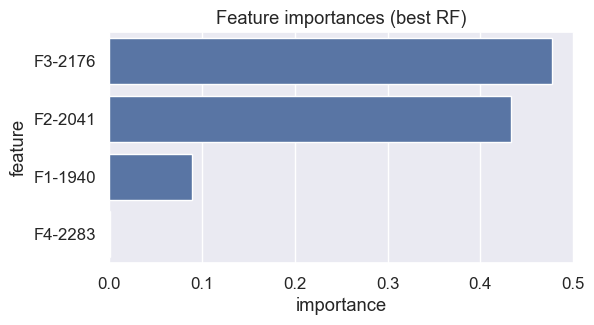

In [62]:
# Feature importance (for tree models) 
if hasattr(best_rf, "feature_importances_"):
    fi = best_rf.feature_importances_
    fi_df = pd.DataFrame({"feature": X.columns, "importance": fi}).sort_values("importance", ascending=False)
    print(fi_df)
    plt.figure(figsize=(6,3))
    sns.barplot(x="importance", y="feature", data=fi_df)
    plt.title("Feature importances (best RF)")
    plt.show()

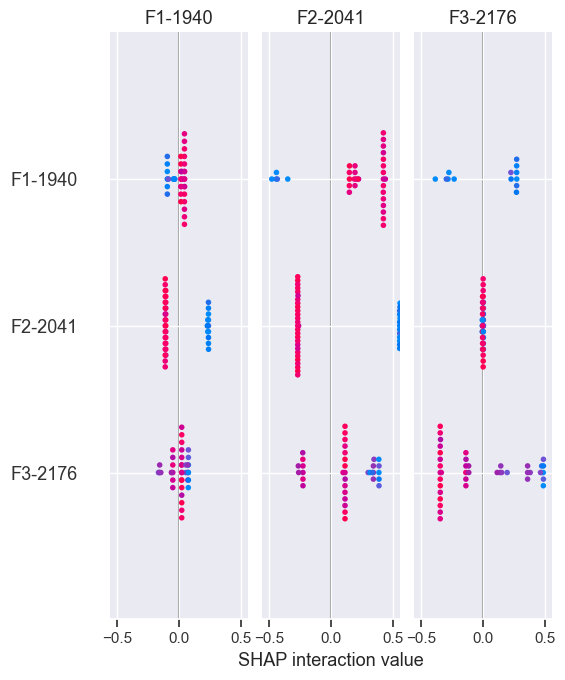

In [63]:
# SHAP 

try:
    import shap
    explainer = shap.TreeExplainer(best_rf)  # works for tree models
    shap_vals = explainer.shap_values(X_test)
    shap.summary_plot(shap_vals, X_test, feature_names=X.columns, show=True)
except Exception as e:
    print("SHAP not run (install shap to enable).", e)